# End-to-End Customer Intelligence Platform
Using Python, SQL and Power BI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("online_retail.csv")

In [ ]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### **DATA CLEANING**

In [ ]:
print("Rows,Columns : ",df.shape)

Rows,Columns :  (541909, 8)


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df=df.dropna(subset=["CustomerID"])

In [ ]:
df.shape

(406829, 8)

In [ ]:
duplicates=df.duplicated().sum()
print("Duplictate rows : ",duplicates)

Duplictate rows :  5225


In [ ]:
df=df.drop_duplicates()

In [ ]:
df.shape

(401604, 8)

In [ ]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [ ]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
df[df["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [ ]:
df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

In [ ]:
df = df[df["Quantity"] > 0]

In [ ]:
df = df[df["UnitPrice"] > 0]

In [ ]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
print("Final Shape:", df.shape)

print("Customers:", df["CustomerID"].nunique())

print("Countries:", df["Country"].nunique())

print("Revenue:", round(df["Revenue"].sum(), 2))

Final Shape: (392692, 9)
Customers: 4338
Countries: 37
Revenue: 8887208.89


# **Export Clean Dataset**

In [ ]:
df.to_csv(
    "cleaned_online_retail.csv",
    index=False
)

# **Exploratory Data Analysis (EDA)**

In [ ]:
print("Total Revenue: £{:,.2f}".format(df["Revenue"].sum()))

print("Total Orders:", df["InvoiceNo"].nunique())

print("Total Customers:", df["CustomerID"].nunique())

print("Average Order Value: £{:,.2f}".format(
    df.groupby("InvoiceNo")["Revenue"].sum().mean()
))

Total Revenue: £8,887,208.89
Total Orders: 18532
Total Customers: 4338
Average Order Value: £479.56


In [ ]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [ ]:
monthly_sales = (
    df.groupby("YearMonth")["Revenue"]
      .sum()
      .reset_index()
)

monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

monthly_sales.head()

,YearMonth,Revenue
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331


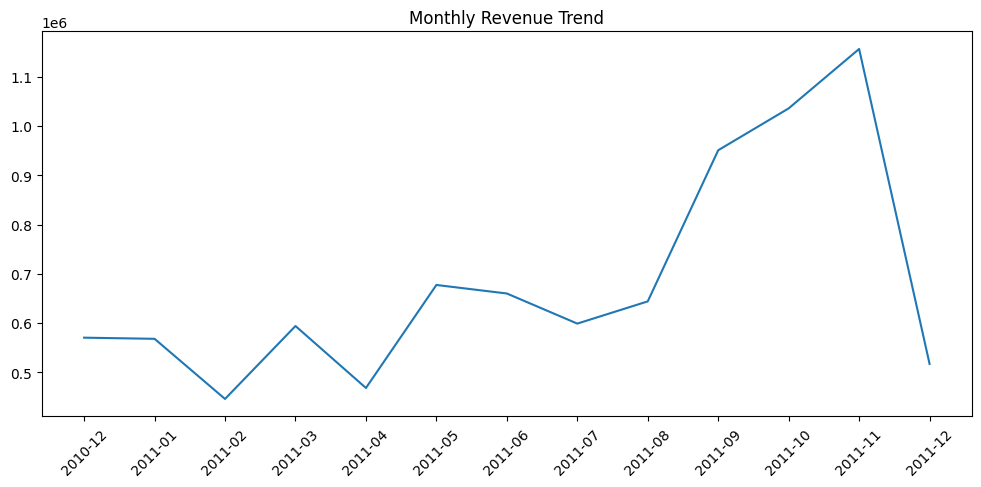

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["Revenue"]
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.show()

In [ ]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


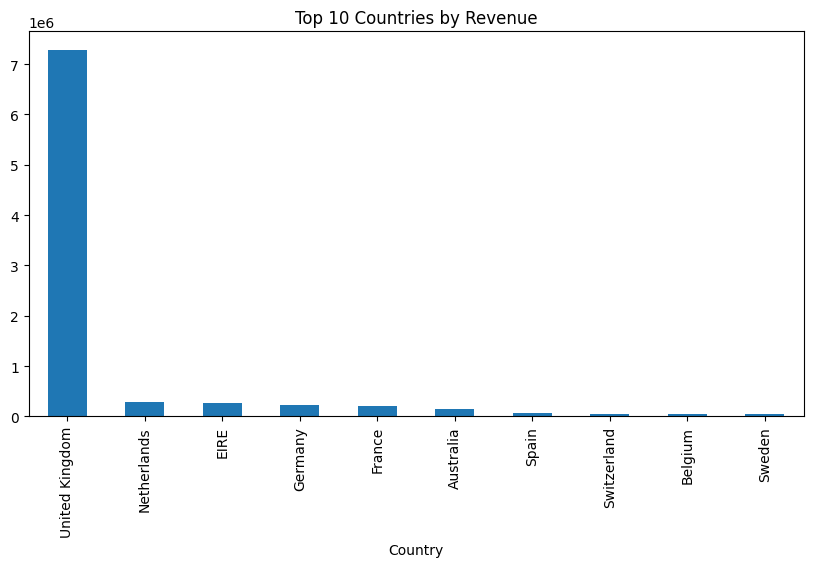

In [ ]:
country_sales.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Revenue")

plt.show()

In [ ]:
top_customers = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


In [ ]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


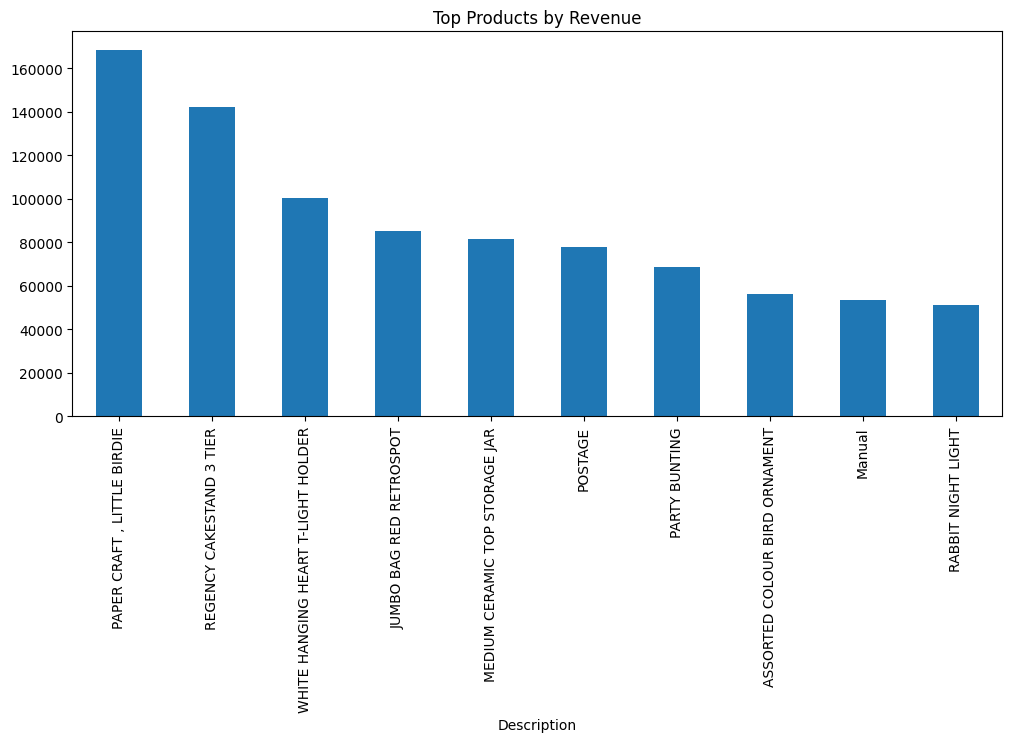

In [ ]:
top_products.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top Products by Revenue")

plt.show()

In [ ]:
customer_rev = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

customer_rev.head()

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17


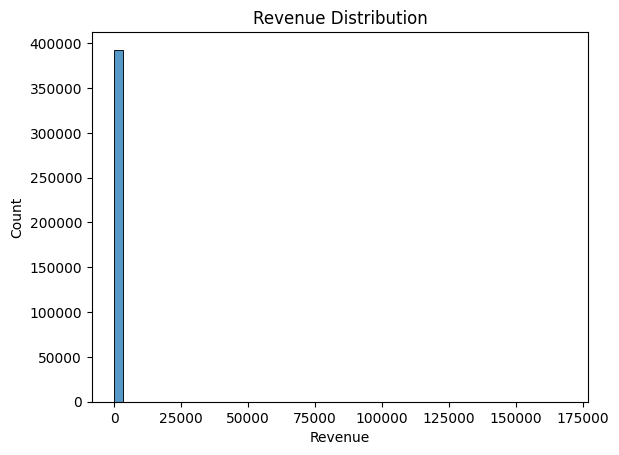

In [ ]:
import seaborn as sns

sns.histplot(
    df["Revenue"],
    bins=50
)

plt.title("Revenue Distribution")

plt.show()

# **Customer RFM Analysis**

In [ ]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [ ]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (
        snapshot_date - x.max()
    ).days,

    "InvoiceNo": "nunique",

    "Revenue": "sum"
})

In [ ]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [ ]:
rfm["R"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [ ]:
rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm["M"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm["RFM_Score"] = (
    rfm["R"].astype(str)
    +
    rfm["F"].astype(str)
    +
    rfm["M"].astype(str)
)

In [ ]:
rfm.sort_values(
    by="Monetary",
    ascending=False
).head(10)

,Recency,Frequency,Monetary,R,F,M,RFM_Score
CustomerID,,,,,,,
14646.0,2,73,280206.02,5,5,5,555
18102.0,1,60,259657.30,5,5,5,555
17450.0,8,46,194390.79,5,5,5,555
16446.0,1,2,168472.50,5,3,5,535
14911.0,1,201,143711.17,5,5,5,555
12415.0,24,21,124914.53,4,5,5,455
14156.0,10,55,117210.08,5,5,5,555
17511.0,3,31,91062.38,5,5,5,555
16029.0,39,63,80850.84,3,5,5,355


In [ ]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


# **Customer Segmentation**

In [ ]:
def segment_customer(row):

    if row["R"] >= 4 and row["F"] >= 4:
        return "Champions"

    elif row["R"] >= 3 and row["F"] >= 3:
        return "Loyal Customers"

    elif row["R"] >= 4:
        return "Potential Loyalists"

    elif row["R"] <= 2 and row["F"] >= 3:
        return "At Risk"

    else:
        return "Others"

In [ ]:
rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [ ]:
rfm["Segment"].value_counts()

,count
Segment,
Others,1416
Champions,1139
Loyal Customers,821
At Risk,643
Potential Loyalists,319


In [ ]:
rfm.groupby(
    "Segment"
)["Monetary"].sum().sort_values(
    ascending=False
)

,Monetary
Segment,
Champions,5913422.081
Loyal Customers,1351084.300
At Risk,798052.511
Others,679430.262
Potential Loyalists,145219.740


In [ ]:
rfm.groupby(
    "Segment"
)["Monetary"].count()

,Monetary
Segment,
At Risk,643
Champions,1139
Loyal Customers,821
Others,1416
Potential Loyalists,319


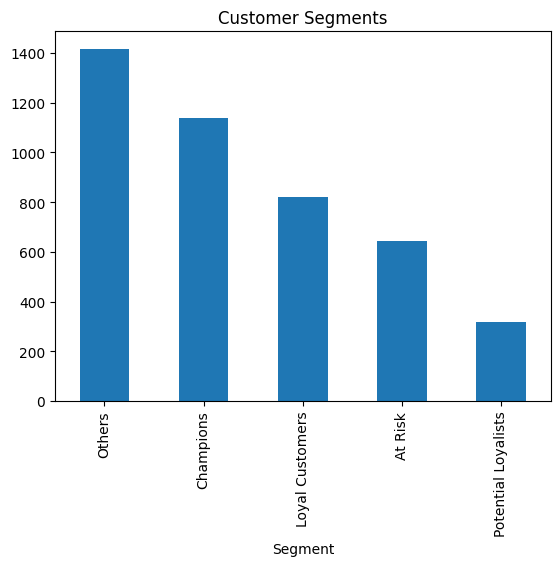

In [ ]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customer Segments"
)

plt.show()

In [ ]:
rfm.to_csv(
    "customer_segments.csv"
)

# **COHORT ANALYSIS**

In [ ]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

In [ ]:
cohort_data = df.copy()

cohort_data["CohortMonth"] = (
    cohort_data.groupby("CustomerID")["InvoiceMonth"]
    .transform("min")
)

In [ ]:
cohort_data[
    ["CustomerID", "InvoiceMonth", "CohortMonth"]
].head()

,CustomerID,InvoiceMonth,CohortMonth
0,17850.0,2010-12,2010-12
1,17850.0,2010-12,2010-12
2,17850.0,2010-12,2010-12
3,17850.0,2010-12,2010-12
4,17850.0,2010-12,2010-12


In [ ]:
invoice_year = cohort_data["InvoiceMonth"].dt.year
invoice_month = cohort_data["InvoiceMonth"].dt.month

cohort_year = cohort_data["CohortMonth"].dt.year
cohort_month = cohort_data["CohortMonth"].dt.month

cohort_data["CohortIndex"] = (
    (invoice_year - cohort_year) * 12
    + (invoice_month - cohort_month)
    + 1
)

In [ ]:
cohort_counts = (
    cohort_data.groupby(
        ["CohortMonth", "CohortIndex"]
    )["CustomerID"]
    .nunique()
    .reset_index()
)

In [ ]:
cohort_table = cohort_counts.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

In [ ]:
cohort_size = cohort_table.iloc[:, 0]

retention = cohort_table.divide(
    cohort_size,
    axis=0
)

In [ ]:
retention.round(3)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366,0.323,0.384,0.363,0.398,0.363,0.349,0.354,0.395,0.374,0.503,0.266
2011-01,1.0,0.221,0.266,0.230,0.321,0.288,0.247,0.242,0.300,0.326,0.365,0.118,NaN
2011-02,1.0,0.187,0.187,0.284,0.271,0.247,0.253,0.279,0.247,0.305,0.068,NaN,NaN
2011-03,1.0,0.150,0.252,0.199,0.223,0.168,0.268,0.230,0.279,0.086,NaN,NaN,NaN
2011-04,1.0,0.213,0.203,0.210,0.197,0.227,0.217,0.260,0.073,NaN,NaN,NaN,NaN
2011-05,1.0,0.190,0.173,0.173,0.208,0.232,0.264,0.095,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.174,0.157,0.264,0.231,0.335,0.095,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.181,0.207,0.223,0.271,0.112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207,0.249,0.243,0.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


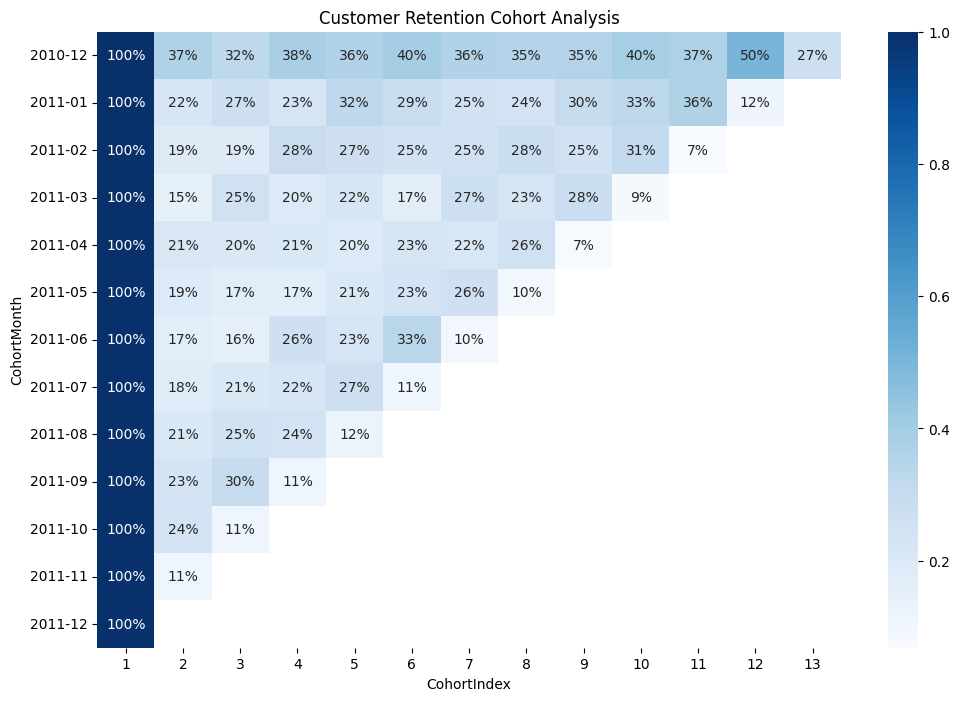

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Retention Cohort Analysis")

plt.show()

# **Customer Lifetime Value (CLV)**

In [ ]:
clv = df.groupby("CustomerID").agg({
    "InvoiceNo":"nunique",
    "Revenue":"sum"
})

clv.columns = [
    "Total_Orders",
    "Total_Revenue"
]

In [ ]:
clv["AOV"] = (
    clv["Total_Revenue"]
    /
    clv["Total_Orders"]
)

In [ ]:
clv["CLV"] = (
    clv["AOV"]
    *
    clv["Total_Orders"]
)

In [ ]:
clv["Tier"] = pd.qcut(
    clv["CLV"],
    q=4,
    labels=[
        "Bronze",
        "Silver",
        "Gold",
        "Platinum"
    ]
)

In [ ]:
clv["Tier"].value_counts()

,count
Tier,
Bronze,1085
Platinum,1085
Silver,1084
Gold,1084


In [ ]:
clv.groupby(
    "Tier"
)["CLV"].sum()

/tmp/ipykernel_7590/2593925064.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clv.groupby(


,CLV
Tier,
Bronze,193166.380
Silver,500706.782
Gold,1155744.351
Platinum,7037591.381


In [ ]:
clv.to_csv("clv.csv")